In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):
    """Message have the type 'list[dict[str,str]]. that add massage function
    in the annotated defines how this state key should be updated,
    in this case it appends the new message to the existing list of the message """
    messages : Annotated[list,add_messages]
    
graph_builder = StateGraph(State)
graph_builder

In [4]:
## LLM
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm = ChatGroq(
    model= 'qwen/qwen3.8-27b',
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.5,
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, client=<groq.resources.chat.completions.Completions object at 0x763e204a70e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x763e204a7e00>, model_name='qwen/qwen3.8-27b', temperature=0.5, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
from langchain_openai import ChatOpenAI
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set. Add it to your .env file or export it in the environment.")

openai_llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=api_key,
)
openai_llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3', 'langchain-openai': '1.6.7'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x763e0f054980>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x763e0f055400>, root_client=<openai.OpenAI object at 0x763e0f0541a0>, root_async

In [6]:
llm = init_chat_model('groq:qwen/qwen3.8-27b')
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, client=<groq.resources.chat.completions.Completions object at 0x763e0f0f0050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x763e0f0f0a50>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
# Node functionality
def chatbot(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

def chatbot_open_ai(state:State):
    return {"messages": [openai_llm.invoke(state['messages'])]}


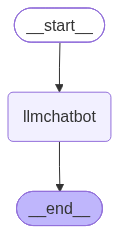

In [8]:
graph_builder = StateGraph(State)

# Adding Node to the graph
graph_builder.add_node("llmchatbot",chatbot)



# Adding the edge to the graph
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge('llmchatbot',END)

# compliling the graph
graph = graph_builder.compile()
graph

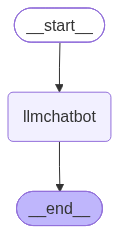

In [9]:
graph_builder_openai = StateGraph(State)

# Adding Node to the graph
graph_builder_openai.add_node("llmchatbot",chatbot_open_ai)



# Adding the edge to the graph
graph_builder_openai.add_edge(START,"llmchatbot")
graph_builder_openai.add_edge('llmchatbot',END)

# compliling the graph
graph_openai = graph_builder_openai.compile()
graph_openai

In [12]:
# ## check the response form the chatbot
# response = graph.invoke({'messages':"hello"})
# response

In [11]:
result = graph_openai.invoke({'messages':"hello"})
result

{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='2f505ae8-ca64-4753-bdc7-15036dbc1c4e'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0f833288d6', 'id': 'chatcmpl-EVtJvtDBx6yyrz84s6uSocS2Ue1Bo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a10ff7-b3cd-7c80-afb6-456c9224c69a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'tot

In [14]:
# user_message =input("Ask the question")
# for event in graph.stream({'messages':user_message}):
#     for message in event.values():
#         print(message['messages'][-1].content)

### Tool adding for the chatbot

In [12]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_result =2)
result = tool.invoke("what is langchain")
result

{'query': 'what is langchain',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.oracle.com/database/what-is-langchain',
   'title': 'What is LangChain? | Oracle',
   'content': 'LangChain is an open source framework for building applications with large language models by connecting models to data, tools, and workflows. It provides building blocks—prompts, retrievers for RAG, tools, and agent patterns, including LangGraph—so LLMs can fetch context, call APIs, and produce structured outputs with tracing and evaluation via LangSmith. In short, LangChain helps development teams move from prototypes to reliable production applications that use AI and AI agents. [...] LangChain is an open source framework for building LLM applications that combine prompt templates, memory, data connectors, tools, retrieval, and AI agents. Its standardized abstractions, including chains, retrievers, and agents, give developers reusable building blocks for orchest

In [13]:
# Custome function
def multiply(a:float,b:float) ->float:
    """ 
    multiply a and b
    Args
    a(flaot): first float value
    b(flaot): second float value
    
    return:
    float : output float
     
    """
    return a*b

In [14]:
tools = [ tool, multiply]

In [15]:
llm_with_tool = openai_llm.bind_tools(tools=tools)
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3', 'langchain-openai': '1.6.7'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x763e0f054980>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x763e0f055400>, root_client=<openai.OpenAI object at 0x7

In [16]:
## Stategraph
from langgraph.graph import StateGraph,END,START
from langgraph.prebuilt import ToolNode, tools_condition


In [17]:
# Node dafination
def tool_calling_llm(state:State):
    return {'messages':[llm_with_tool.invoke(state['messages'])]}

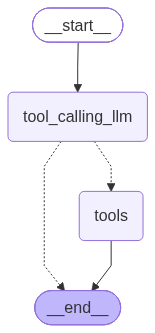

In [18]:
#graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# add the edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools',END)

builder_graph = builder.compile()

builder_graph

In [22]:
open_response = builder_graph.invoke({'messages': "what is cuurent ai news "})
open_response

{'messages': [HumanMessage(content='what is cuurent ai news ', additional_kwargs={}, response_metadata={}, id='5ebbb161-398f-4747-96d4-fad598ccfb58'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1245, 'total_tokens': 1272, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5e38b2795', 'id': 'chatcmpl-EVs5ny8NfOsFxIm9k09kwC47tbQSK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a10faf-b277-7001-822c-c0d38c11bcda-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current AI news', 'topic': 'news', 'time_ra

In [23]:
open_response['messages']

[HumanMessage(content='what is cuurent ai news ', additional_kwargs={}, response_metadata={}, id='5ebbb161-398f-4747-96d4-fad598ccfb58'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1245, 'total_tokens': 1272, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5e38b2795', 'id': 'chatcmpl-EVs5ny8NfOsFxIm9k09kwC47tbQSK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a10faf-b277-7001-822c-c0d38c11bcda-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current AI news', 'topic': 'news', 'time_range': 'week'},

In [25]:
open_response['messages'][-1].content

'{"query": "current AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Noimos.ai launched a customer engagement agent to automate behavior-based marketing actions. The agent tracks customer activity patterns, triggers contextual messages across digital channels, and manages retention workflows.\\n\\nOpenArt introduced OpenArt Arena, a benchmark platform for creative image models. The system evaluates generative model performance through side-by-side user preference testing and ranks visual output quality across specific artistic styles. [...] Gong released Mission Callisto, an AI sales enrichment layer for revenue teams. The update captures customer interaction signals across sales calls, extracts deal insights, enriches buyer profiles, and syncs actionable account metrics into sales workflows.\\n\\nGuidelin

In [28]:
for m in open_response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is cuurent ai news 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_4pyuPrl5TzIyyaGXoOvpUBHG)
 Call ID: call_4pyuPrl5TzIyyaGXoOvpUBHG
  Args:
    query: current AI news
    topic: news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "current AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Noimos.ai launched a customer engagement agent to automate behavior-based marketing actions. The agent tracks customer activity patterns, triggers contextual messages across digital channels, and manages retention workflows.\n\nOpenArt introduced OpenArt Arena, a benchmark platform for 

In [32]:
# open_response = builder_graph.invoke({'messages': "what is cuurent ai news "})
# open_response
# for m in open_response['messages']:
#     m.pretty_print()

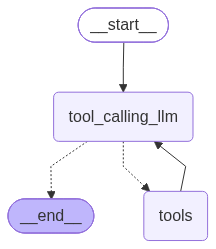

In [35]:
# Graph
builder = StateGraph(State)

# Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges
builder.add_edge(START, "tool_calling_llm")

# If LLM makes a tool call -> tools
# If LLM does not make a tool call -> END
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# After executing the tool, go back to the LLM
builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
builder_graph = builder.compile()

builder_graph
